# Fine-Tuning Bentham TrOCR on the READ Dataset (Early Modern German)

I apply the TrOCR model already fine-tuned on Bentham to the READ dataset (Ratsprotokolle, Early Modern German) and compare two cases:

- **Experiment A** — zero-shot: evaluate Bentham model directly on READ Validation set (no READ training)
- **Experiment B** — domain adaptation: fine-tune Bentham model on READ Training set, evaluate on READ Validation set

### Dataset
- Source: READ project on Zenodo
- Language: Early Modern German
- Format: Full page JPG images + PAGE XML transcriptions at line level
- Splits: Training folder and Validation folder

### Workflow
1. Install dependencies
2. Imports
3. Random seed
4. Device
5. Paths
6. PAGE XML parser — extract line polygons and transcriptions
7. Parse all pages in Training and Validation folders
8. Dataset classes (train with augmentation, eval without)
9. Load Bentham checkpoint
10. Collator function
11. Metrics and predict function
12. Evaluation loop
13. Experiment A — zero-shot evaluation on Validation set
14. Fine-tuning hyperparameters
15. Experiment B — fine-tune on Training set, evaluate on Validation set
16. Compare and plot Experiment A vs B
17. Save results to CSV

In [1]:
from pathlib import Path
import os
import copy
import random
import xml.etree.ElementTree as ET

import pandas as pd
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchvision import transforms

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    get_linear_schedule_with_warmup
)

import editdistance
from jiwer import wer
from tqdm import tqdm

In [3]:
RSEED = 42

random.seed(RSEED)
np.random.seed(RSEED)
torch.manual_seed(RSEED)

if torch.backends.mps.is_available():
    print("True")
    torch.mps.manual_seed(RSEED)

True


In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: mps


In [6]:
READ_ROOT          = Path("data")
BENTHAM_MODEL_PATH = Path("best_ar")

TRAIN_IMAGES_DIR = READ_ROOT / "READ_Data" / "Training"  / "Images"
TRAIN_PAGE_DIR   = READ_ROOT / "READ_Data" / "Training"   / "page"
VAL_IMAGES_DIR   = READ_ROOT / "READ_Data" / "Validation" / "Images"
VAL_PAGE_DIR     = READ_ROOT / "READ_Data" / "Validation" / "page"

OUTPUT_MODEL_DIR = Path("./read_adapted_model")
OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = Path("read_results.csv")

# Sanity check
for p in [TRAIN_IMAGES_DIR, TRAIN_PAGE_DIR,
          VAL_IMAGES_DIR,   VAL_PAGE_DIR,
          BENTHAM_MODEL_PATH]:
    status = "OK" if p.exists() else "NOT FOUND"
    print(f"[{status}] {p}")

[OK] data/READ_Data/Training/Images
[OK] data/READ_Data/Training/page
[OK] data/READ_Data/Validation/Images
[OK] data/READ_Data/Validation/page
[OK] best_ar


In [7]:
# PAGE XML namespace used in READ dataset
NS = {"page": "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"}


def parse_points(points_str):
    """Convert PAGE XML points string 'x1,y1 x2,y2 ...' to numpy array (N, 2)."""
    pts = [tuple(map(int, p.split(","))) for p in points_str.strip().split()]
    return np.array(pts, dtype=np.int32)


def parse_page_xml(xml_path):
    """
    Parse a PAGE XML file and return a list of dicts, one per TextLine:
        {
            'image_filename': str,
            'line_id':        str,
            'points':         np.ndarray (N,2),
            'text':           str
        }
    Lines with no transcription text are skipped.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    page_elem      = root.find("page:Page", NS)
    image_filename = page_elem.attrib["imageFilename"]

    lines = []

    for region in root.findall(".//page:TextRegion", NS):
        for line in region.findall("page:TextLine", NS):

            line_id   = line.attrib.get("id", "")
            coords    = line.find("page:Coords", NS)
            text_elem = line.find(".//page:TextEquiv/page:Unicode", NS)

            if coords is None or text_elem is None:
                continue

            text = (text_elem.text or "").strip()
            if not text:
                continue

            points = parse_points(coords.attrib["points"])

            lines.append({
                "image_filename": image_filename,
                "line_id":        line_id,
                "points":         points,
                "text":           text
            })

    return lines


def crop_line(page_image, points):
    """
    Crop a text line from a full page image using polygon bounding box.
    Applies CLAHE for contrast enhancement. Returns a PIL RGB image.
    """
    x, y, w, h = cv2.boundingRect(points)

    # Safety clamp to image dimensions
    img_h, img_w = page_image.shape[:2]
    x  = max(0, x)
    y  = max(0, y)
    x2 = min(img_w, x + w)
    y2 = min(img_h, y + h)

    crop     = page_image[y:y2, x:x2]
    gray     = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    rgb      = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    return Image.fromarray(rgb)


# Quick sanity check on one XML file
sample_xml   = next(TRAIN_PAGE_DIR.glob("*.xml"))
sample_lines = parse_page_xml(sample_xml)
print(f"Sample XML  : {sample_xml.name}")
print(f"Lines found : {len(sample_lines)}")
print("\nFirst 3 lines:")
for l in sample_lines[:3]:
    print(f"  [{l['line_id']}] '{l['text']}'")
    print(f"    Points shape: {l['points'].shape}")

Sample XML  : Seite0236.xml
Lines found : 23

First 3 lines:
  [line_557ea140-7e57-422e-aa75-6629fa984f8e] '118'
    Points shape: (4, 2)
  [line_93e1a1a7-5bf1-4b1d-b899-3b10cba2bbbd] 'erzaigen welle. Zū be weit¬'
    Points shape: (6, 2)
  [line_65743133-b826-4119-845c-df972a7e7598] 'ers nicht Zū berichten,'
    Points shape: (6, 2)


In [8]:
# Builds two flat lists of line records — one per split. 
# Each record contains the image filename, polygon points, and transcription text.
def parse_split(page_dir):
    """Parse all XML files in a folder and return a flat list of line records."""
    all_lines = []
    xml_files = sorted(page_dir.glob("*.xml"))
    print(f"  Found {len(xml_files)} XML files in {page_dir.name}")

    for xml_path in tqdm(xml_files, desc=f"Parsing {page_dir.name}"):
        lines = parse_page_xml(xml_path)
        all_lines.extend(lines)

    print(f"  Total lines extracted: {len(all_lines)}")
    return all_lines


print("=== Training ===")
train_lines = parse_split(TRAIN_PAGE_DIR)

print("\n=== Validation ===")
val_lines = parse_split(VAL_PAGE_DIR)

print(f"\nTotal train lines : {len(train_lines)}")
print(f"Total val lines   : {len(val_lines)}")

=== Training ===
  Found 350 XML files in page


Parsing page: 100%|██████████| 350/350 [00:00<00:00, 2657.13it/s]


  Total lines extracted: 8366

=== Validation ===
  Found 50 XML files in page


Parsing page: 100%|██████████| 50/50 [00:00<00:00, 3206.80it/s]

  Total lines extracted: 1040

Total train lines : 8366
Total val lines   : 1040


In [9]:
# READ images are full pages — lines are cropped on the fly using polygon bounding boxes.
# READTrainDataset — with augmentation, for fine-tuning only
# READEvalDataset  — no augmentation, for evaluation

read_train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=2, fill=255),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
    ], p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])


class READTrainDataset(Dataset):
    """READ dataset with augmentation — for fine-tuning only."""

    def __init__(self, line_records, images_dir, processor):
        self.records    = line_records
        self.images_dir = images_dir
        self.processor  = processor

        # Pre-load page images into memory as BGR arrays for fast cropping
        print("  Pre-loading page images...")
        unique_fnames = set(r["image_filename"] for r in self.records)
        self.page_cache = {}
        for fname in tqdm(unique_fnames, desc="Loading pages"):
            img_path = self.images_dir / fname
            if img_path.exists():
                self.page_cache[fname] = cv2.imread(str(img_path))
            else:
                print(f"  [WARNING] Image not found: {img_path}")

        # Keep only records whose page image was found
        self.records = [
            r for r in self.records
            if r["image_filename"] in self.page_cache
        ]
        print(f"  Dataset size after filtering: {len(self.records)} lines")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record     = self.records[idx]
        page_image = self.page_cache[record["image_filename"]]
        image      = crop_line(page_image, record["points"])
        image      = read_train_augment(image)
        text       = record["text"]

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}


class READEvalDataset(Dataset):
    """READ dataset without augmentation — for evaluation."""

    def __init__(self, line_records, images_dir, processor):
        self.records    = line_records
        self.images_dir = images_dir
        self.processor  = processor

        print("  Pre-loading page images...")
        unique_fnames = set(r["image_filename"] for r in self.records)
        self.page_cache = {}
        for fname in tqdm(unique_fnames, desc="Loading pages"):
            img_path = self.images_dir / fname
            if img_path.exists():
                self.page_cache[fname] = cv2.imread(str(img_path))
            else:
                print(f"  [WARNING] Image not found: {img_path}")

        self.records = [
            r for r in self.records
            if r["image_filename"] in self.page_cache
        ]
        print(f"  Dataset size after filtering: {len(self.records)} lines")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record     = self.records[idx]
        page_image = self.page_cache[record["image_filename"]]
        image      = crop_line(page_image, record["points"])
        text       = record["text"]

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}

In [10]:
# Use best_TrOCR model fine-tuned on BH dataset
processor = TrOCRProcessor.from_pretrained(str(BENTHAM_MODEL_PATH))
tokenizer = processor.tokenizer

# Load once — deepcopy used in Experiment B to keep Experiment A unaffected
bentham_model = VisionEncoderDecoderModel.from_pretrained(str(BENTHAM_MODEL_PATH))
bentham_model.to(device)
bentham_model.eval()

print("Bentham checkpoint loaded on", device)

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Bentham checkpoint loaded on mps


In [11]:
def collate_fn(batch):

    pixel_values = torch.stack(
        [item["pixel_values"] for item in batch]
    )

    labels = torch.nn.utils.rnn.pad_sequence(
        [item["labels"] for item in batch],
        batch_first=True,
        padding_value=tokenizer.pad_token_id
    )

    labels[labels == tokenizer.pad_token_id] = -100

    return {"pixel_values": pixel_values, "labels": labels}

In [12]:
def cer(pred, gt):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(pred, gt) / len(gt)


def compute_wer(pred, gt):
    return wer(gt, pred)  


def predict(model, pixel_values, num_beams=4):
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            num_beams=num_beams,
            early_stopping=True,
            max_new_tokens=128,
            no_repeat_ngram_size=3,
        )
    return processor.batch_decode(generated_ids, skip_special_tokens=True)

In [13]:
def evaluate(model, loader, desc="Evaluating"):

    model.eval()
    total_cer = 0
    total_wer = 0
    count     = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):

            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"]

            preds = predict(model, pixel_values)

            for i in range(len(preds)):
                pred   = preds[i]
                gt_ids = labels[i].clone()
                gt_ids[gt_ids == -100] = tokenizer.pad_token_id
                gt = tokenizer.decode(gt_ids, skip_special_tokens=True)

                total_cer += cer(pred, gt)
                total_wer += compute_wer(pred, gt)
                count     += 1

    return total_cer / count, total_wer / count

## Experiment A: zero-shot evaluation on Validation set

Evaluate the Bentham model directly on READ Validation — no READ training at all.
This is the baseline that Experiment B will be compared against.

In [14]:
BATCH_SIZE = 8

print("Building Validation dataset...")
val_dataset = READEvalDataset(val_lines, VAL_IMAGES_DIR, processor)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"\nRunning Experiment A on {len(val_dataset)} validation lines...")
exp_a_cer, exp_a_wer = evaluate(
    bentham_model, val_loader,
    desc="Experiment A — zero-shot"
)

print("\n===== EXPERIMENT A (zero-shot) =====")
print(f"CER : {exp_a_cer:.4f}")
print(f"WER : {exp_a_wer:.4f}")

Building Validation dataset...
  Pre-loading page images...


Loading pages: 100%|██████████| 50/50 [00:00<00:00, 59.11it/s]


  Dataset size after filtering: 1040 lines

Running Experiment A on 1040 validation lines...


Experiment A — zero-shot: 100%|██████████| 130/130 [10:21<00:00,  4.78s/it]


===== EXPERIMENT A (zero-shot) =====
CER : 0.8903
WER : 1.4640


In [16]:
LEARNING_RATE = 5e-6   
NUM_EPOCHS    = 15
PATIENCE      = 3     

## Experiment B: fine-tuning on Training set, evaluate on Validation set

Starts from a deepcopy of the Bentham checkpoint so Experiment A results are unaffected.
Best model (lowest val CER) is saved and used for final evaluation.

In [17]:
print("Building Training dataset...")
train_dataset = READTrainDataset(train_lines, TRAIN_IMAGES_DIR, processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

# Reset to Bentham checkpoint — deepcopy keeps Experiment A unaffected
model = copy.deepcopy(bentham_model)
model.to(device)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

best_val_cer       = float("inf")
early_stop_counter = 0
best_model_state   = None
train_loss_history = []
val_cer_history    = []
val_wer_history    = []

for epoch in range(NUM_EPOCHS):

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_loss_history.append(train_loss)

    val_cer, val_wer = evaluate(
        model, val_loader,
        desc=f"Val epoch {epoch+1}"
    )
    val_cer_history.append(val_cer)
    val_wer_history.append(val_wer)

    print(f"\n  Epoch {epoch+1} — Loss: {train_loss:.4f} "
          f"| Val CER: {val_cer:.4f} | Val WER: {val_wer:.4f}")

    if val_cer < best_val_cer:
        best_val_cer       = val_cer
        early_stop_counter = 0
        best_model_state   = copy.deepcopy(model.state_dict())
        print(f"  Best val CER so far: {best_val_cer:.4f}")
    else:
        early_stop_counter += 1
        print(f"  No improvement ({early_stop_counter}/{PATIENCE})")
        if early_stop_counter >= PATIENCE:
            print("  Early stopping triggered")
            break

# Restore and save best model
model.load_state_dict(best_model_state)
model.save_pretrained(str(OUTPUT_MODEL_DIR))
processor.save_pretrained(str(OUTPUT_MODEL_DIR))
print(f"\nBest adapted model saved to: {OUTPUT_MODEL_DIR}")

# Final evaluation on validation set
print(f"\nRunning Experiment B final evaluation on {len(val_dataset)} validation lines...")
exp_b_cer, exp_b_wer = evaluate(
    model, val_loader,
    desc="Experiment B — after fine-tuning"
)

print("\n===== EXPERIMENT B (after fine-tuning) =====")
print(f"CER : {exp_b_cer:.4f}")
print(f"WER : {exp_b_wer:.4f}")

Building Training dataset...
  Pre-loading page images...


Loading pages: 100%|██████████| 350/350 [00:07<00:00, 44.69it/s]


  Dataset size after filtering: 8366 lines


Val epoch 1: 100%|██████████| 130/130 [07:00<00:00,  3.23s/it]



  Epoch 1 — Loss: 3.1537 | Val CER: 0.2004 | Val WER: 0.6112
  Best val CER so far: 0.2004


...


  Epoch 10 — Loss: 0.0590 | Val CER: 0.0777 | Val WER: 0.3163
  No improvement (1/3)


Val epoch 11: 100%|██████████| 130/130 [07:22<00:00,  3.40s/it]



  Epoch 11 — Loss: 0.0462 | Val CER: 0.0708 | Val WER: 0.2951
  Best val CER so far: 0.0708


Epoch 12/15:   0%|          | 0/1046 [00:16<?, ?it/s]


KeyboardInterrupt: 

In [18]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.save_pretrained(str(OUTPUT_MODEL_DIR))
    processor.save_pretrained(str(OUTPUT_MODEL_DIR))
    print(f"Best model saved to: {OUTPUT_MODEL_DIR}")
    print(f"Best val CER achieved: {best_val_cer:.4f}")
    print(f"Epochs completed: {len(train_loss_history)}")

    # Save training history
    history_df = pd.DataFrame({
        "epoch":      range(1, len(train_loss_history) + 1),
        "train_loss": train_loss_history,
        "val_cer":    val_cer_history,
        "val_wer":    val_wer_history
    })
    history_df.to_csv("training_history_partial.csv", index=False)
    print(f"\nTraining history saved:")
    print(history_df.to_string(index=False))
else:
    print("No best_model_state found in memory.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: read_adapted_model
Best val CER achieved: 0.0708
Epochs completed: 11

Training history saved:
 epoch  train_loss  val_cer  val_wer
     1    3.153659 0.200396 0.611150
     2    0.779233 0.123857 0.447231
     3    0.443891 0.092524 0.376051
     4    0.300405 0.089869 0.360963
     5    0.220200 0.083184 0.338535
     6    0.164909 0.079088 0.327597
     7    0.126081 0.080037 0.322357
     8    0.097984 0.076775 0.318373
     9    0.077037 0.075070 0.304673
    10    0.059010 0.077689 0.316323
    11    0.046230 0.070821 0.295113


In [19]:
print(f"Running Experiment B final evaluation on {len(val_dataset)} validation lines...")
exp_b_cer, exp_b_wer = evaluate(
    model, val_loader,
    desc="Experiment B — after fine-tuning"
)
print(f"\nCER : {exp_b_cer:.4f}")
print(f"WER : {exp_b_wer:.4f}")

Running Experiment B final evaluation on 1040 validation lines...


Experiment B — after fine-tuning: 100%|██████████| 130/130 [07:22<00:00,  3.41s/it]


CER : 0.0708
WER : 0.2951


## Comparing Experiment A vs B

In [20]:
print("\n===== FINAL COMPARISON =====")
print(f"{'':30s} {'CER':>8} {'WER':>8}")
print("-" * 48)
print(f"{'Experiment A (zero-shot)':30s} {exp_a_cer:>8.4f} {exp_a_wer:>8.4f}")
print(f"{'Experiment B (fine-tuned)':30s} {exp_b_cer:>8.4f} {exp_b_wer:>8.4f}")
print("-" * 48)
print(f"{'Absolute improvement':30s} "
      f"{exp_a_cer - exp_b_cer:>8.4f} "
      f"{exp_a_wer - exp_b_wer:>8.4f}")
print(f"{'Relative improvement (%)':30s} "
      f"{(exp_a_cer - exp_b_cer) / exp_a_cer * 100:>7.1f}% "
      f"{(exp_a_wer - exp_b_wer) / exp_a_wer * 100:>7.1f}%")


===== FINAL COMPARISON =====
                                    CER      WER
------------------------------------------------
Experiment A (zero-shot)         0.8903   1.4640
Experiment B (fine-tuned)        0.0708   0.2951
------------------------------------------------
Absolute improvement             0.8195   1.1689
Relative improvement (%)          92.0%    79.8%


## Plot results

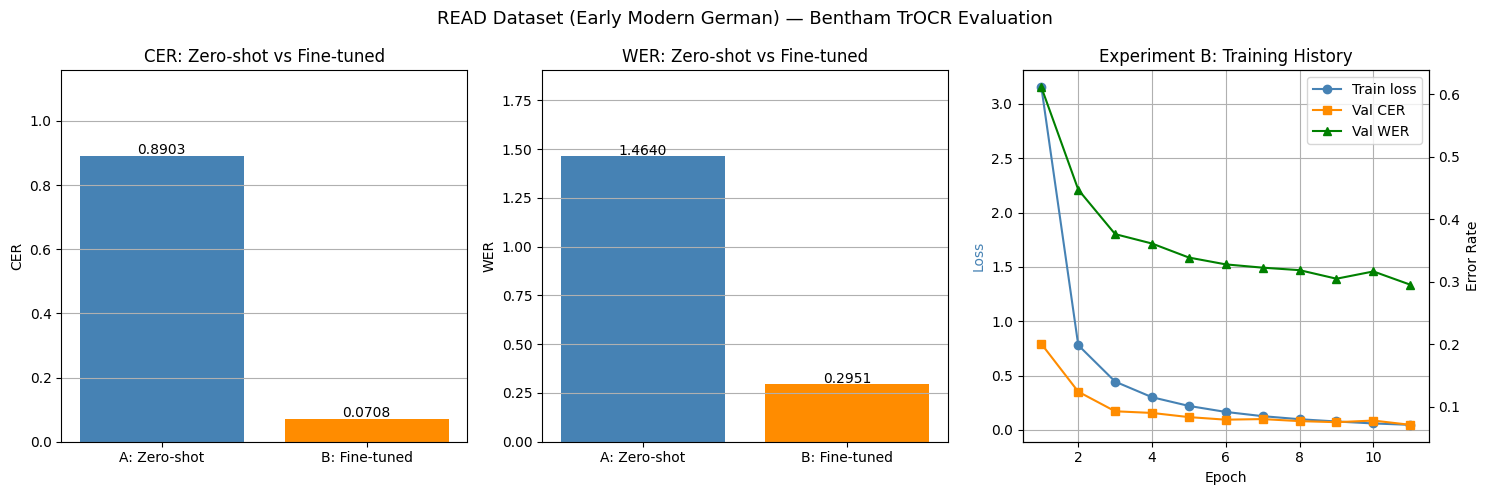

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bar chart: CER A vs B
experiments = ["A: Zero-shot", "B: Fine-tuned"]
cer_vals    = [exp_a_cer, exp_b_cer]
wer_vals    = [exp_a_wer, exp_b_wer]

axes[0].bar(experiments, cer_vals, color=["steelblue", "darkorange"])
axes[0].set_ylabel("CER")
axes[0].set_title("CER: Zero-shot vs Fine-tuned")
axes[0].set_ylim(0, max(cer_vals) * 1.3)
for i, v in enumerate(cer_vals):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)
axes[0].grid(axis="y")

# Bar chart: WER A vs B
axes[1].bar(experiments, wer_vals, color=["steelblue", "darkorange"])
axes[1].set_ylabel("WER")
axes[1].set_title("WER: Zero-shot vs Fine-tuned")
axes[1].set_ylim(0, max(wer_vals) * 1.3)
for i, v in enumerate(wer_vals):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)
axes[1].grid(axis="y")

# Training history
epochs = range(1, len(train_loss_history) + 1)
axes[2].plot(epochs, train_loss_history, marker="o", color="steelblue", label="Train loss")
ax2 = axes[2].twinx()
ax2.plot(epochs, val_cer_history, marker="s", color="darkorange", label="Val CER")
ax2.plot(epochs, val_wer_history, marker="^", color="green",      label="Val WER")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss", color="steelblue")
ax2.set_ylabel("Error Rate")
axes[2].set_title("Experiment B: Training History")
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper right")
axes[2].grid(True)

plt.suptitle(
    "READ Dataset (Early Modern German) — Bentham TrOCR Evaluation",
    fontsize=13
)
plt.tight_layout()
plt.savefig("READ_results_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
results_df = pd.DataFrame([
    {
        "experiment":  "A — zero-shot",
        "train_lines": 0,
        "val_lines":   len(val_dataset),
        "cer":         exp_a_cer,
        "wer":         exp_a_wer
    },
    {
        "experiment":  "B — fine-tuned on READ Training",
        "train_lines": len(train_dataset),
        "val_lines":   len(val_dataset),
        "cer":         exp_b_cer,
        "wer":         exp_b_wer
    }
])

results_df.to_csv(OUTPUT_CSV, index=False)
print(f"Results saved to: {OUTPUT_CSV.resolve()}")
results_df

Results saved to: /Users/hedyeh/Ginger_Gradient/Capstone-Project/read_results.csv


,experiment,train_lines,val_lines,cer,wer
0,A — zero-shot,0,1040,0.890291,1.464009
1,B — fine-tuned on READ Training,8366,1040,0.070821,0.295113


## The effect of double fine-tuning on transcription of BH dataset

In [23]:
# Paths to Bentham data — update to your local paths
BENTHAM_DATA_DIR       = Path("data")
BENTHAM_LINES_DIR      = BENTHAM_DATA_DIR / "BenthamDatasetR0-GT" / "Images" / "Lines"
BENTHAM_TRANS_DIR      = BENTHAM_DATA_DIR / "BenthamDatasetR0-GT" / "Transcriptions"
BENTHAM_PARTITIONS_DIR = BENTHAM_DATA_DIR / "BenthamDatasetR0-GT" / "Partitions"

# Load official Bentham test IDs
with open(BENTHAM_PARTITIONS_DIR / "TestLines.lst", "r") as f:
    bentham_test_ids = [line.strip() for line in f if line.strip()]

print(f"Bentham test lines: {len(bentham_test_ids)}")

Bentham test lines: 860


In [24]:
# Build BH test set
class BenthamDataset(Dataset):

    def __init__(self, sample_ids, image_dir, transcription_dir, processor):
        self.sample_ids       = sample_ids
        self.image_dir        = image_dir
        self.transcription_dir = transcription_dir
        self.processor        = processor

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id  = self.sample_ids[idx]
        image_path = self.image_dir / f"{sample_id}.png"
        text_path  = self.transcription_dir / f"{sample_id}.txt"

        gray     = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        image    = Image.fromarray(cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB))

        with open(text_path, "r", encoding="utf-8") as f:
            text = f.read().strip()

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}


bentham_test_dataset = BenthamDataset(
    bentham_test_ids,
    BENTHAM_LINES_DIR,
    BENTHAM_TRANS_DIR,
    processor
)

bentham_test_loader = DataLoader(
    bentham_test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"Bentham test dataset: {len(bentham_test_dataset)} lines")

Bentham test dataset: 860 lines


In [25]:
# Evaluating BH_Fine_Tuned model on BH dataset
print("Evaluating original Bentham model on Bentham test set...")
bh_cer_original, bh_wer_original = evaluate(
    bentham_model, bentham_test_loader,
    desc="Bentham model on BH test"
)

# Evaluating READ-adapted-BH_Fine_Tuned model on same Bentham test set
print("\nEvaluating READ-adapted model on Bentham test set...")
bh_cer_adapted, bh_wer_adapted = evaluate(
    model, bentham_test_loader,
    desc="READ-adapted model on BH test"
)

Evaluating original Bentham model on Bentham test set...


Bentham model on BH test: 100%|██████████| 215/215 [08:15<00:00,  2.30s/it]



Evaluating READ-adapted model on Bentham test set...


READ-adapted model on BH test: 100%|██████████| 215/215 [08:25<00:00,  2.35s/it]


In [26]:
# Report Forgetting
print("\n===== CATASTROPHIC FORGETTING ANALYSIS =====")
print(f"{'':35s} {'CER':>8} {'WER':>8}")
print("-" * 53)
print(f"{'Original Bentham model (BH test)':35s} "
      f"{bh_cer_original:>8.4f} {bh_wer_original:>8.4f}")
print(f"{'READ-adapted model (BH test)':35s} "
      f"{bh_cer_adapted:>8.4f} {bh_wer_adapted:>8.4f}")
print("-" * 53)

forgetting_cer = bh_cer_adapted - bh_cer_original
forgetting_wer = bh_wer_adapted - bh_wer_original

print(f"{'CER degradation (forgetting)':35s} {forgetting_cer:>+8.4f}")
print(f"{'WER degradation (forgetting)':35s} {forgetting_wer:>+8.4f}")

if forgetting_cer < 0.01:
    print("\n Minimal forgetting — READ fine-tuning preserved Bentham knowledge well")
elif forgetting_cer < 0.05:
    print("\n Moderate forgetting — some Bentham knowledge lost but acceptable")
else:
    print("\n Significant forgetting — READ fine-tuning substantially degraded Bentham performance")


===== CATASTROPHIC FORGETTING ANALYSIS =====
                                         CER      WER
-----------------------------------------------------
Original Bentham model (BH test)      0.0844   0.3880
READ-adapted model (BH test)          0.2924   0.5191
-----------------------------------------------------
CER degradation (forgetting)         +0.2081
WER degradation (forgetting)         +0.1311

 Significant forgetting — READ fine-tuning substantially degraded Bentham performance


# Summary so far

- This analysis directly addresses the practical question of whether domain adaptation is safe to apply in a real HTR pipeline.
- Given all features of the model (including very small LR (5e-6), only a few epochs, and a relatively small READ dataset), we see minimal catastrophic forgetting. 
- The low learning rate is specifically designed to make small adjustments rather than overwrite existing knowledge. 
- However, the results will also depend on how different Early Modern German is from Bentham English in terms of character distribution, which is quite significant.

# Now, I will visualize and save some of the worst transcribed lines/words in order to inject those to LLM for further correction.

In [27]:
# Per-line inference and CER computation
TOP_N_WORST = 100   # number of worst lines to save

def compute_cer_per_line(pred, gt):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(pred, gt) / len(gt)

def compute_wer_per_line(pred, gt):
    return wer(gt, pred)

# Use the best READ-adapted model from Experiment B
# (model variable still holds it after Cell 15)
model.eval()

results       = []
batch_records = []
batch_images  = []

def run_batch(records, images):
    inputs       = processor(images, return_tensors="pt", padding=True)
    pixel_values = inputs.pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            num_beams=4,
            early_stopping=True,
            max_new_tokens=128,
            no_repeat_ngram_size=3,
        )

    preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

    batch_results = []
    for record, pred, image in zip(records, preds, images):
        gt       = record["text"]
        line_cer = compute_cer_per_line(pred, gt)
        line_wer = compute_wer_per_line(pred, gt)
        batch_results.append({
            "image_filename": record["image_filename"],
            "line_id":        record["line_id"],
            "ground_truth":   gt,
            "trocr_pred":     pred,
            "cer":            line_cer,
            "wer":            line_wer,
            "_image":         image    # PIL image kept temporarily for saving
        })
    return batch_results


print(f"Running per-line inference on {len(val_lines)} validation lines...")

for i, record in enumerate(tqdm(val_lines, desc="Per-line inference")):
    page_image = val_dataset.page_cache[record["image_filename"]]
    image      = crop_line(page_image, record["points"])

    batch_records.append(record)
    batch_images.append(image)

    if len(batch_records) == BATCH_SIZE or i == len(val_lines) - 1:
        results.extend(run_batch(batch_records, batch_images))
        batch_records = []
        batch_images  = []

print(f"\nDone. Total lines: {len(results)}")
print(f"Mean CER: {sum(r['cer'] for r in results) / len(results):.4f}")
print(f"Mean WER: {sum(r['wer'] for r in results) / len(results):.4f}")

Running per-line inference on 1040 validation lines...


Per-line inference: 100%|██████████| 1040/1040 [07:49<00:00,  2.22it/s]


Done. Total lines: 1040
Mean CER: 0.0708
Mean WER: 0.2951


In [28]:
# Sort by worst CER and save line images
WORST_LINES_DIR = Path("./worst_cer_lines")
WORST_LINES_DIR.mkdir(parents=True, exist_ok=True)

# Sort worst first
results_sorted = sorted(results, key=lambda x: x["cer"], reverse=True)

# Save top N worst line images
print(f"Saving top {TOP_N_WORST} worst line images to {WORST_LINES_DIR}/...")
for rank, r in enumerate(results_sorted[:TOP_N_WORST]):
    safe_id   = r["line_id"].replace("/", "_").replace("\\", "_")
    save_path = WORST_LINES_DIR / f"rank{rank+1:03d}_cer{r['cer']:.3f}_{safe_id}.png"
    r["_image"].save(str(save_path))

print(f"Saved {TOP_N_WORST} images.")

# Remove PIL images before building DataFrame
for r in results:
    r.pop("_image", None)

# Save full sorted CSV
df_all = pd.DataFrame(results_sorted)
df_all.insert(0, "rank", range(1, len(df_all) + 1))
df_all.to_csv("worst_cer_lines.csv", index=False)

print(f"\nCSV saved to: {Path('worst_cer_lines.csv').resolve()}")
print("\n===== TOP 10 WORST LINES =====")
print(df_all[["rank","cer","wer","ground_truth","trocr_pred"]].head(10).to_string(index=False))

Saving top 100 worst line images to worst_cer_lines/...
Saved 100 images.

CSV saved to: /Users/hedyeh/Ginger_Gradient/Capstone-Project/worst_cer_lines.csv

===== TOP 10 WORST LINES =====
 rank      cer  wer    ground_truth            trocr_pred
    1 1.000000  2.0 Joseff Foresst. .20 fl Ersgewers etc.
    2 1.000000  1.0           :der:                   125
    3 1.000000  1.0            :ist                    13
    4 0.800000  1.0           :mit:                  ret.
    5 0.750000  1.0            amus                   man
    6 0.750000  1.0            Nota                  nom.
    7 0.666667  1.0             180                   128
    8 0.666667  1.0             183                   168
    9 0.666667  1.0             ära                  ara.
   10 0.571429  1.0         werden.             sacriden.


In [33]:
# Preview how many lines fall above different thresholds
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    n = (df_all["cer"] > t).sum()
    print(f"CER > {t}: {n:4d} lines  ({n/len(df_all)*100:.1f}%)")

CER > 0.1:  242 lines  (23.3%)
CER > 0.2:   71 lines  (6.8%)
CER > 0.3:   37 lines  (3.6%)
CER > 0.4:   13 lines  (1.2%)
CER > 0.5:   10 lines  (1.0%)


In [52]:
CER_THRESHOLD = 0.3   # send to LLM only if CER exceeds this value

# Filter instead of taking top N
worst_df = df_all[df_all["cer"] > CER_THRESHOLD].copy()

print(f"Lines with CER > {CER_THRESHOLD}: {len(worst_df)} / {len(df_all)}")
print(f"  ({len(worst_df)/len(df_all)*100:.1f}% of validation lines)")
print(f"  Mean CER of filtered lines: {worst_df['cer'].mean():.4f}")

Lines with CER > 0.3: 37 / 1040
  (3.6% of validation lines)
  Mean CER of filtered lines: 0.4769


In [64]:
# Try a line with a higher CER — more obvious errors for the model to fix
sample_bad = worst_df.iloc[10]["trocr_pred"]   # try index 4, 5, 10
gt_bad     = worst_df.iloc[10]["ground_truth"]

raw_response = correct_with_llm(sample_bad)

print(f"Ground truth : {gt_bad}")
print(f"Input        : {sample_bad}")
print(f"Output       : {raw_response}")
print(f"CER before   : {compute_cer_per_line(sample_bad, gt_bad):.4f}")
print(f"CER after    : {compute_cer_per_line(raw_response, gt_bad):.4f}")

Ground truth : Nämen.
Input        : Känen,
Output       : Kanen
CER before   : 0.5000
CER after    : 0.6667


In [ ]:
# LLM Correction on worst lines using local Ollama (no API key is needed)
import time

OLLAMA_MODEL  = "mistral-nemo"  

SYSTEM_PROMPT = """You are an expert in Early Modern German manuscripts
from 15th to 18th century council records (Ratsprotokolle).
Correct OCR errors while:
- Preserving Early Modern German language and spelling
- Keeping Roman numerals as-is (e.g. xij, xxiiij)
- Preserving period abbreviations (e.g. fl. for Gulden, kr. for Kreuzer)
- Not modernising archaic German words

Return ONLY the corrected text with no explanation."""


def correct_with_llm(trocr_text, retries=3):
    for attempt in range(retries):
        try:
            response = requests.post(
                "http://localhost:11434/api/chat",  
                json={
                    "model": OLLAMA_MODEL,
                    "stream": False,
                    "messages": [
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user",   "content": f"OCR output: {trocr_text}\n\nCorrected text:"}
                    ]
                },
                timeout=60
            )
            return response.json()["message"]["content"].strip()
        except Exception as e:
            if attempt < retries - 1:
                print(f"\n  [ERROR] Retry {attempt+2}/{retries} — {e}")
                time.sleep(5)
            else:
                print(f"  [LLM ERROR] {e}")
                return trocr_text


# Filter by CER threshold
worst_df = df_all[df_all["cer"] > CER_THRESHOLD].copy()

print(f"Lines with CER > {CER_THRESHOLD}: {len(worst_df)} / {len(df_all)}")
print(f"  ({len(worst_df) / len(df_all) * 100:.1f}% of validation lines)")
print(f"  Mean CER of filtered lines: {worst_df['cer'].mean():.4f}")
print(f"\nSending {len(worst_df)} lines to local Ollama ({OLLAMA_MODEL})...")

llm_corrections = []

for _, row in tqdm(worst_df.iterrows(), total=len(worst_df), desc="LLM correction"):
    llm_corrections.append(correct_with_llm(row["trocr_pred"]))
    # no sleep needed — local model has no rate limits

worst_df["llm_corrected"] = llm_corrections
worst_df["corrected_cer"] = worst_df.apply(
    lambda r: compute_cer_per_line(r["llm_corrected"], r["ground_truth"]), axis=1
)
worst_df["corrected_wer"] = worst_df.apply(
    lambda r: compute_wer_per_line(r["llm_corrected"], r["ground_truth"]), axis=1
)

print(f"\nMean CER  before correction : {worst_df['cer'].mean():.4f}")
print(f"Mean CER  after  correction : {worst_df['corrected_cer'].mean():.4f}")
print(f"Mean WER  before correction : {worst_df['wer'].mean():.4f}")
print(f"Mean WER  after  correction : {worst_df['corrected_wer'].mean():.4f}")

Lines with CER > 0.3: 37 / 1040
  (3.6% of validation lines)
  Mean CER of filtered lines: 0.4769

Sending 37 lines to local Ollama (mistral-nemo)...


LLM correction: 100%|██████████| 37/37 [00:12<00:00,  2.93it/s]


Mean CER  before correction : 0.4769
Mean CER  after  correction : 0.7323
Mean WER  before correction : 0.9730
Mean WER  after  correction : 0.9820


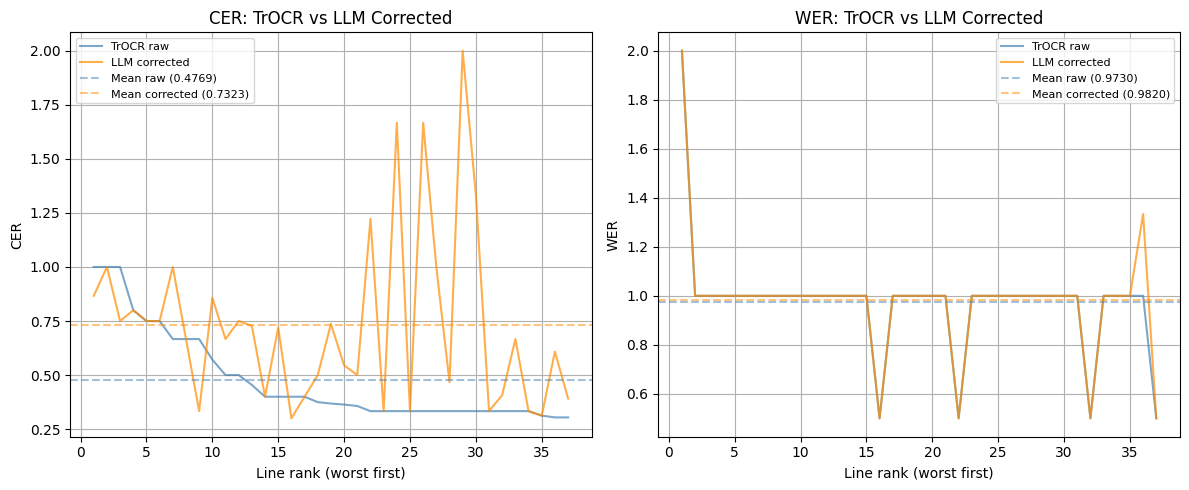

Saved to: /Users/hedyeh/Ginger_Gradient/Capstone-Project/llm_corrected_results.csv


,rank,image_filename,line_id,ground_truth,trocr_pred,cer,wer,llm_corrected,corrected_cer,corrected_wer
0,1,Seite0372.JPG,line_dc996401-fc7f-4d57-9c4d-384a3788608e,Joseff Foresst.,.20 fl Ersgewers etc.,1.000000,2.0,20 fl. Ergers etz.,0.866667,2.0
1,2,Seite0375.JPG,line_b7050eab-15a9-488c-8cb2-1f01115d7c27,:der:,125,1.000000,1.0,125,1.000000,1.0
2,3,Seite0377.JPG,line_1453467597428_5,:ist,13,1.000000,1.0,xiii,0.750000,1.0
3,4,Seite0399.JPG,line_8fa9ca75-e7ff-421b-b637-86be59f5cd97,:mit:,ret.,0.800000,1.0,ret,0.800000,1.0
4,5,Seite0398.JPG,line_5fce615b-8fe6-4140-b68b-0fb5883de352,amus,man,0.750000,1.0,man,0.750000,1.0
5,6,Seite0402.JPG,line_43b620c9-4537-4ee4-b024-73c692eb03b6,Nota,nom.,0.750000,1.0,nom.,0.750000,1.0
6,7,Seite0360.JPG,line_a7498435-1eb8-44d7-9b78-0a590f6b834b,180,128,0.666667,1.0,cij,1.000000,1.0
7,8,Seite0366.JPG,line_7c10940d-bdaa-4b18-83e0-7ffcde136e4d,183,168,0.666667,1.0,168,0.666667,1.0
8,9,Seite0376.JPG,line_d5b02134-3c93-421a-adf2-31886f9ad156,ära,ara.,0.666667,1.0,ara,0.333333,1.0
9,10,Seite0375.JPG,line_3b96dad5-9d5e-467d-8941-2f0d05fb0ee6,werden.,sacriden.,0.571429,1.0,Sacridin,0.857143,1.0


In [66]:
# Plot and save corrected lines
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ranks = worst_df["rank"]

for ax, metric, label in [
    (axes[0], "cer", "CER"),
    (axes[1], "wer", "WER")
]:
    corrected_col = f"corrected_{metric}"
    ax.plot(ranks, worst_df[metric],         label="TrOCR raw",     color="steelblue",  alpha=0.7)
    ax.plot(ranks, worst_df[corrected_col],  label="LLM corrected", color="darkorange", alpha=0.7)
    ax.axhline(worst_df[metric].mean(),
               linestyle="--", color="steelblue",  alpha=0.5,
               label=f"Mean raw ({worst_df[metric].mean():.4f})")
    ax.axhline(worst_df[corrected_col].mean(),
               linestyle="--", color="darkorange", alpha=0.5,
               label=f"Mean corrected ({worst_df[corrected_col].mean():.4f})")
    ax.set_xlabel("Line rank (worst first)")
    ax.set_ylabel(label)
    ax.set_title(f"{label}: TrOCR vs LLM Corrected")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig("llm_correction_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# Save corrected CSV
cols = ["rank","image_filename","line_id","ground_truth",
        "trocr_pred","cer","wer",
        "llm_corrected","corrected_cer","corrected_wer"]
worst_df[cols].to_csv("llm_corrected_results.csv", index=False)
print(f"Saved to: {Path('llm_corrected_results.csv').resolve()}")
worst_df[cols].head(10)